# Penguin Classification

### Overview
The Penguin Classification project involves using the Palmer Penguins dataset to classify penguin species based on physical measurements. This dataset is a popular alternative to the Iris dataset for classification tasks and provides an opportunity to explore various classification algorithms.

### Dataset
The Palmer Penguins dataset is available in the `seaborn` library. It includes measurements of penguins such as bill length, bill depth, flipper length, and body mass, along with the species information.

### Objectives

#### Data Exploration and Preprocessing:
- Load the Palmer Penguins dataset.
- Inspect the dataset for missing values and basic statistics.
- Preprocess the data by handling missing values and encoding categorical variables.

#### Exploratory Data Analysis (EDA):
- Analyze the distribution of each feature.
- Visualize relationships between features and species using pair plots and correlation matrices.
- Assess class distribution to understand any potential class imbalance.

#### Model Building and Evaluation:
- Build classification models using algorithms like Logistic Regression, Decision Trees, and k-Nearest Neighbors (k-NN).
- Evaluate model performance using metrics such as accuracy, precision, recall, and F1-score.

#### Model Tuning:
- Fine-tune hyperparameters to improve model performance.
- Use techniques like cross-validation to assess model stability and performance.

### Methods and Tools

#### Libraries Used:
- `seaborn` for loading and visualizing the dataset.
- `scikit-learn` for machine learning algorithms and preprocessing.
- `numpy` and `pandas` for data manipulation.
- `matplotlib` and `seaborn` for data visualization.

Logistic Regression Performance:
Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        31
   Chinstrap       1.00      1.00      1.00        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67

Confusion Matrix:


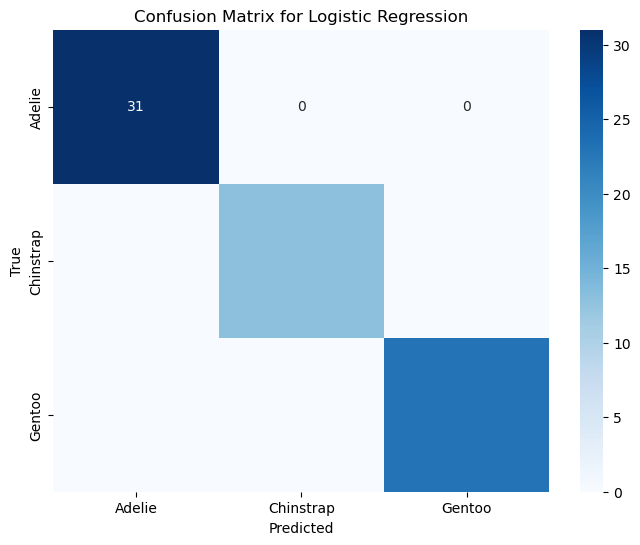


Decision Tree Performance:
Accuracy: 0.99
Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        31
   Chinstrap       0.93      1.00      0.96        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67

Confusion Matrix:


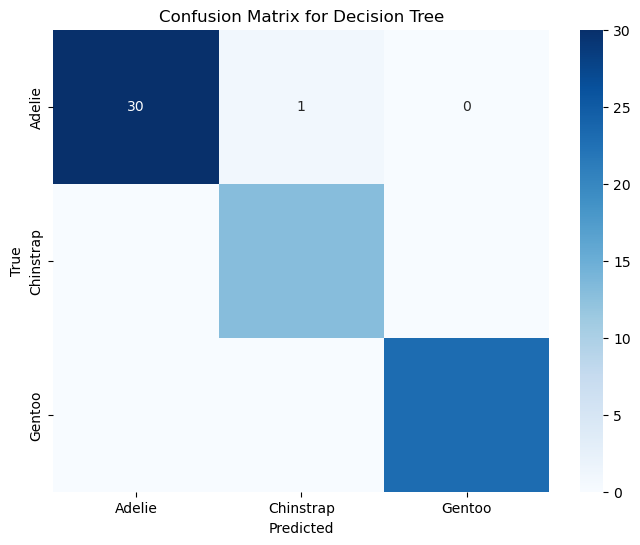


k-Nearest Neighbors Performance:
Accuracy: 0.99
Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        31
   Chinstrap       0.93      1.00      0.96        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67

Confusion Matrix:


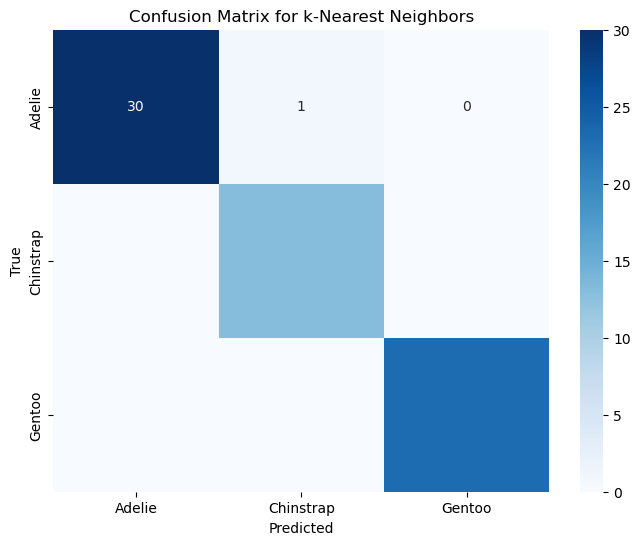

In [3]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
penguins = sns.load_dataset('penguins')

# Data Preprocessing
penguins = penguins.dropna()  # Drop rows with missing values
X = penguins.drop(columns='species')
y = penguins['species']

# Encode categorical variables
X = pd.get_dummies(X)
le = LabelEncoder()
y = le.fit_transform(y)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'k-Nearest Neighbors': KNeighborsClassifier()
}

# Train and evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name} Performance:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix for {name}')
    plt.show()
    print()